# Class-Level (Attribute) Performance

**Feeds:** RQ3 (span vs. attribute reliability, and whether the PT/EN gap
differs systematically at the attribute level).

`results.csv`'s `f1`/`f1_r` columns are span-level only for every template
-- type is recorded but never used to score (`src/evaluate.py::strict_metrics`).
This notebook derives a type-aware, per-class metric from
`detailed_results.csv` via `_common.compute_class_level_metrics` (see the
module docstring for the exact TP/FP/FN attribution rules), for the best
template per (model, language).

Only `cls_*` templates predict a type at all -- models whose best template
is `ext_*` (extract-only) have no class-level signal and are excluded from
the charts below (this is reported explicitly, not silently dropped).


In [1]:
import sys
sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import _common as c

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 100)


In [2]:
best_templates = c.load_best_templates()
detailed = pd.concat([c.load_detailed("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
best_detailed = c.filter_to_best_templates(detailed, best_templates)

# ext_* templates never predict a type, so a model whose actual test-stage
# template is ext_* would otherwise show a misleading row of all-zero F1
# (real recall=0 on every class, indistinguishable in a heatmap from "not
# measured"). Drop those (language, model) pairs before computing class
# metrics -- their absence from the heatmap below *is* the signal.
actual_template = best_detailed.drop_duplicates(["language", "model"])[["language", "model", "template"]]
ext_only_pairs = set(
    map(tuple, actual_template[actual_template["template"].str.startswith("ext")][["language", "model"]].values)
)
print("Excluded from class-level analysis (actual test-stage template is extract-only, no type prediction):")
print(sorted(ext_only_pairs))

best_detailed_cls = best_detailed[
    ~best_detailed.set_index(["language", "model"]).index.isin(ext_only_pairs)
].reset_index(drop=True)


[filter_to_best_templates] english/qwen3_4b: prompt_selection best template ('cls_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
[filter_to_best_templates] portuguese/qwen3_4b: prompt_selection best template ('ext_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
Excluded from class-level analysis (actual test-stage template is extract-only, no type prediction):
[('english', 'gemma3_1b'), ('portuguese', 'gemma3_1b')]


## Per-class F1 heatmap, per language (fine-grained classes)

Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\03_class_f1_heatmap_fine.pdf


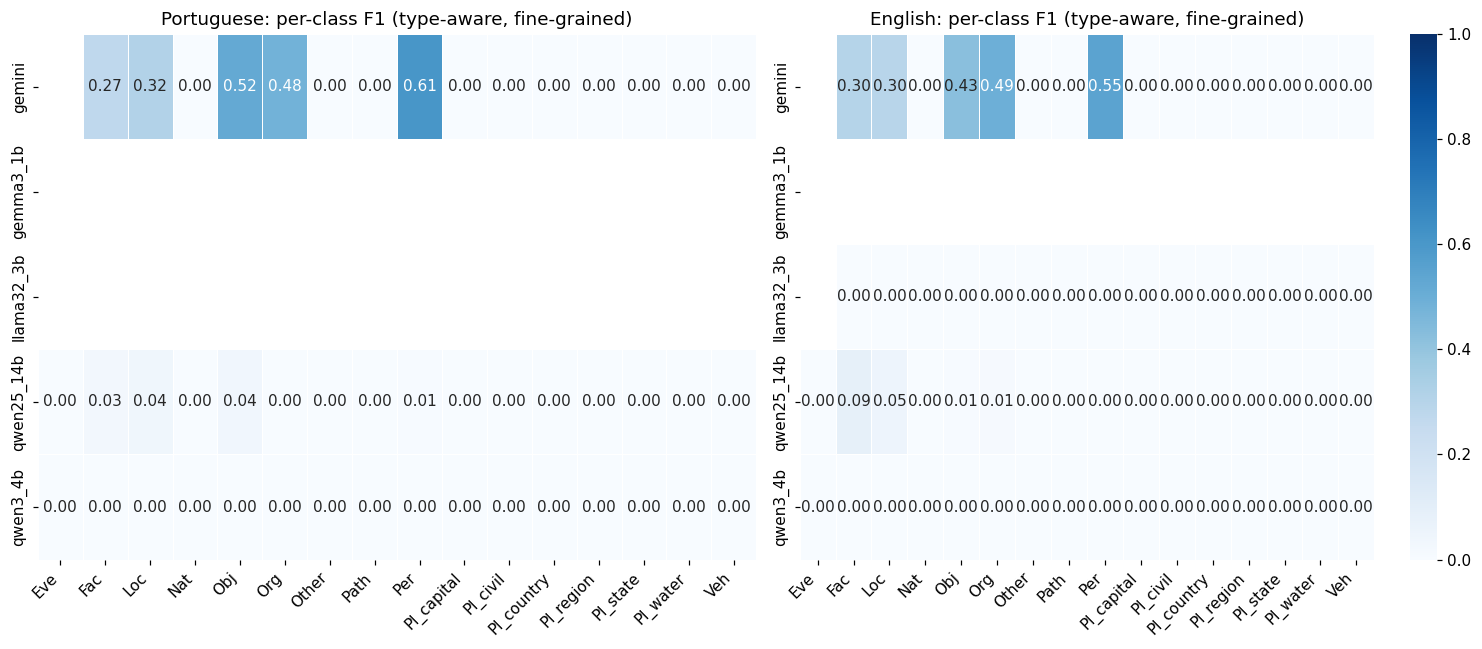

In [3]:
def heatmap_by_language(metrics_df, title_suffix, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for i, (ax, lang) in enumerate(zip(axes, c.LANGUAGE_ORDER)):
        sub = metrics_df[metrics_df["language"] == lang]
        pivot = sub.pivot(index="model", columns="cls", values="f1").reindex(c.MODEL_ORDER)
        sns.heatmap(
            pivot, ax=ax, cmap=c.HEATMAP_CMAP, vmin=0, vmax=1, annot=True, fmt=".2f",
            cbar=(i == len(c.LANGUAGE_ORDER) - 1), linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{lang.capitalize()}: {title_suffix}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    c.save_fig(fig, fname)
    plt.show()


class_metrics = c.compute_class_level_metrics(best_detailed_cls, group_cols=["language", "model"])
heatmap_by_language(class_metrics, "per-class F1 (type-aware, fine-grained)", "03_class_f1_heatmap_fine")


## Coarse-grained view (location subtypes collapsed)

Gold annotations use fine-grained location subtypes (`Pl_capital`,
`Pl_civil`, `Pl_country`, `Pl_region`, `Pl_state`, `Pl_water`) that model
outputs never reproduce -- predictions only ever use the generic `Loc`. The
fine-grained heatmap above shows this as a wall of false negatives on every
`Pl_*` class, which is a label-granularity mismatch rather than an
extraction failure. The view below collapses those into `Loc` via
`_common.coarsen_types` for a fairer comparison.


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\03_class_f1_heatmap_coarse.pdf


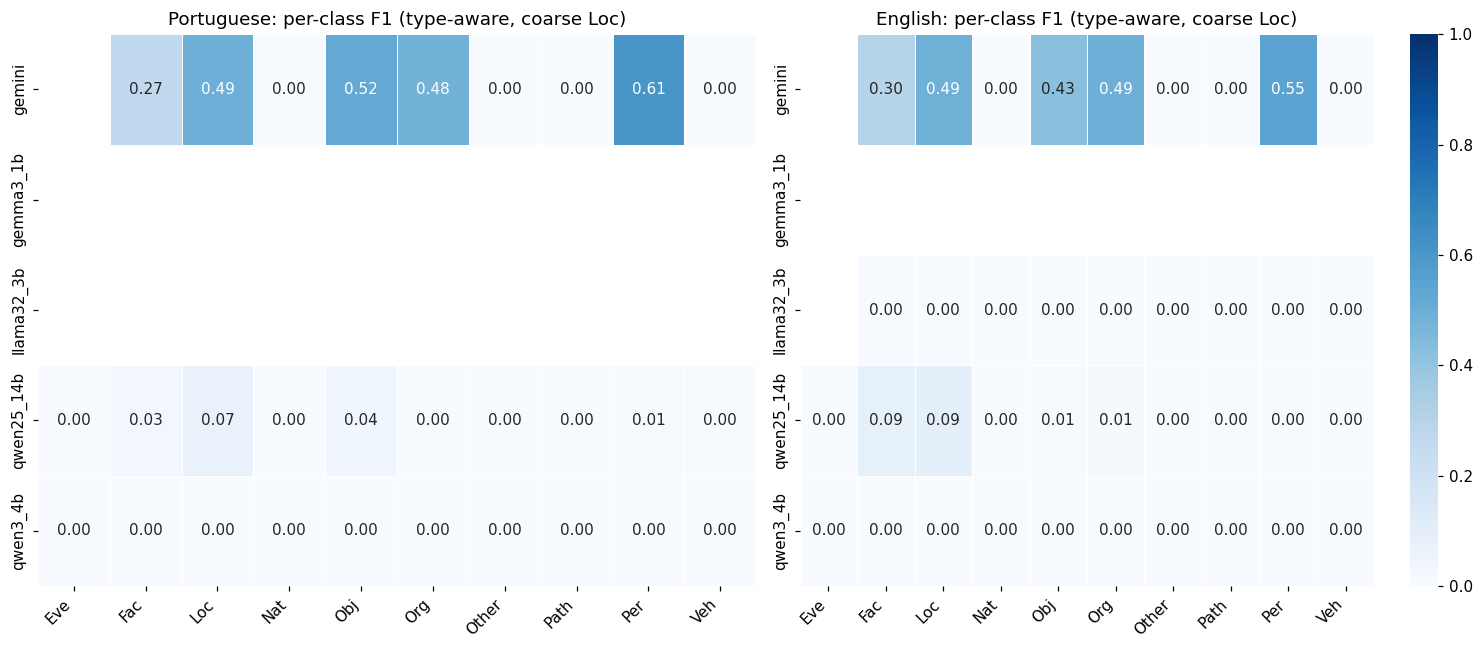

In [4]:
best_detailed_coarse = c.coarsen_types(best_detailed_cls)
class_metrics_coarse = c.compute_class_level_metrics(best_detailed_coarse, group_cols=["language", "model"])
heatmap_by_language(class_metrics_coarse, "per-class F1 (type-aware, coarse Loc)", "03_class_f1_heatmap_coarse")


## Span-level vs. attribute-level ceiling gap

In [5]:
macro_attr = (
    class_metrics_coarse.groupby(["language", "model"], as_index=False)["f1"]
    .mean()
    .rename(columns={"f1": "f1_macro_attr"})
)

test_results = pd.concat([c.load_results("test", lang) for lang in c.LANGUAGE_ORDER], ignore_index=True)
span_f1 = c.filter_to_best_templates(test_results, best_templates)[["language", "model", "f1"]].rename(columns={"f1": "f1_span"})

gap = span_f1.merge(macro_attr, on=["language", "model"], how="inner")
gap["gap"] = gap["f1_span"] - gap["f1_macro_attr"]
gap.sort_values(["language", "model"])


[filter_to_best_templates] english/qwen3_4b: prompt_selection best template ('cls_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').
[filter_to_best_templates] portuguese/qwen3_4b: prompt_selection best template ('ext_exp') has no matching rows here; falling back to the single template actually run in this stage ('cls_def_exp').


,language,model,f1_span,f1_macro_attr,gap
2,english,gemini,0.540468,0.251139,0.289329
3,english,llama32_3b,0.017229,0.000000,0.017229
4,english,qwen25_14b,0.228795,0.020165,0.208630
5,english,qwen3_4b,0.256082,0.000000,0.256082
0,portuguese,gemini,0.558736,0.264063,0.294674
1,portuguese,qwen25_14b,0.232546,0.014382,0.218165
6,portuguese,qwen3_4b,0.248721,0.000000,0.248721


Saved C:\Users\davib\Desktop\MSc_DataScience\thesis\gpt_struct_me\report\Figures\results\03_span_vs_attribute_ceiling_gap.pdf


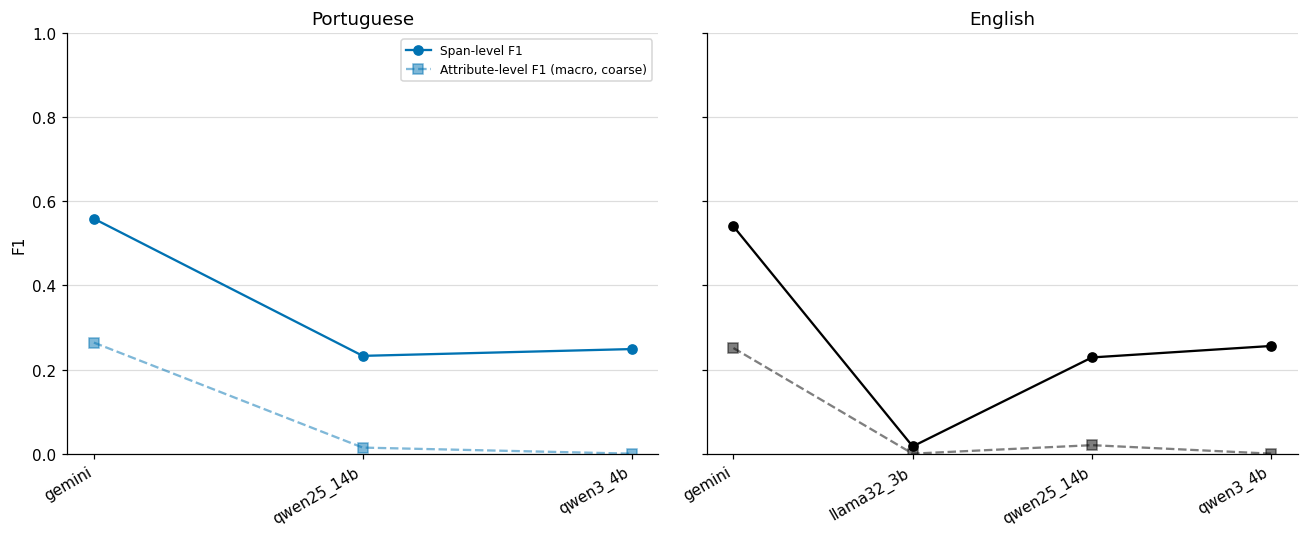

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, lang in zip(axes, c.LANGUAGE_ORDER):
    sub = gap[gap["language"] == lang].sort_values("model")
    x = np.arange(len(sub))
    ax.plot(x, sub["f1_span"], "o-", color=c.LANGUAGE_COLORS[lang], label="Span-level F1")
    ax.plot(x, sub["f1_macro_attr"], "s--", color=c.LANGUAGE_COLORS[lang], alpha=0.5, label="Attribute-level F1 (macro, coarse)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=30, ha="right")
    ax.set_title(lang.capitalize())
    ax.set_ylim(0, 1)
    c.style_axis(ax)
axes[0].set_ylabel("F1")
axes[0].legend(fontsize=8)
c.save_fig(fig, "03_span_vs_attribute_ceiling_gap")
plt.show()


## Synthesis

- Feeds **RQ3**: the per-class heatmaps show which classes (Person, Location, Organization, ...) each model is comparatively strong/weak on, per language.
- The ceiling-gap chart directly answers "does the model plateau at span identification": a large gap between the solid (span) and dashed (attribute) line means most of the span-level F1 does not survive once attribute correctness is required.
- Compare gap sizes PT vs EN to see whether the span-to-attribute drop differs systematically by language.
- Models excluded above (extract-only best template) have no attribute signal at all -- itself a data point for RQ1 (their best prompt never asked for classification in the first place).
- A row can also be all-zero without being excluded: `qwen3_4b`'s `cls_def_exp` template is a classify template, but it almost never populates a parseable type even on otherwise-correct (TP) spans -- so it scores 0 recall on every class despite being asked to classify. That is a weak-instruction-following failure, distinct from the ext_* exclusion above, and worth calling out separately when writing the RQ3 prose.
